# Metaclonotype API Examples

This notebook demonstrates how to build and analyze metaclonotypes using mirpy.

**Metaclonotypes** group clonotypes that are functionally similar (share convergent
CDR3 sequences or belong to the same antigen-binding family).  They allow
**functional diversity** metrics that are more robust to clonal expansion than
raw clonotype counts.

## Workflow

1. Load a real TRB repertoire from the AIRR benchmark.
2. Build metaclonotypes with the high-level `cluster_metaclonotypes` API.
3. Summarize and visualize clusters.
4. Compare functional vs clonotypic diversity metrics.
5. Build metaclonotypes from ALICE/TCRNET enrichment results.

In [1]:
# Environment versions
import platform
import sys
import polars as pl
import importlib.metadata as _meta

print(f'Python {platform.python_version()}')
for pkg in ['mirpy-lib', 'polars', 'numpy', 'igraph']:
    try:
        print(f'  {pkg}: {_meta.version(pkg)}')
    except _meta.PackageNotFoundError:
        pass

Python 3.12.12
  mirpy-lib: 1.1.0
  polars: 1.40.1
  numpy: 1.26.4
  igraph: 1.0.0


In [2]:
# Imports and data loading
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from mir.biomarkers.metaclonotype_cluster import (
    MetaclonotypeClusterConfig,
    cluster_metaclonotypes,
)
from mir.biomarkers.alice import add_alice_metadata
from mir.common.diversity import summarize_clonotypes, hill_curve_clonotypes
from mir.common.metaclonotype import (
    functional_diversity,
    functional_hill_curve,
    summarize_metaclonotypes,
)
from mir.common.parser import VDJtoolsParser
from mir.common.repertoire import LocusRepertoire
from mir.common.sampling import downsample
from mir.utils.notebook_assets import ensure_airr_benchmark

plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# Download AIRR benchmark data on first run (cached after that)
benchmark_root = ensure_airr_benchmark(allow_patterns=['vdjtools/**'])
vdjtools_dir = benchmark_root / 'vdjtools'

# Load one aging-cohort TRB sample and downsample to 20k reads for speed
sample_path = vdjtools_dir / 'A3-i101.txt.gz'
clonotypes = VDJtoolsParser(sep='\t').parse(str(sample_path))
rep_full = LocusRepertoire(clonotypes=clonotypes, locus='TRB')
rep = downsample(rep_full, 20_000, random_seed=42)
print(f'Loaded: {rep_full.clonotype_count:,} clonotypes')
print(f'Downsampled to {rep.clonotype_count:,} clonotypes @ 20k reads')

/Users/mikesh/vcs/mirpy/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded: 1,150,027 clonotypes
Downsampled to 17,147 clonotypes @ 20k reads


In [3]:
# Build edit-distance metaclonotypes using the high-level cluster_metaclonotypes API
# MetaclonotypeClusterConfig holds all method-specific parameters
cfg = MetaclonotypeClusterConfig(
    method='edit_distance',
    metric='hamming',
    threshold=1,
    graph_algo='components',
    min_cluster_size=2,
    n_jobs=4,
)

t0 = time.perf_counter()
meta = cluster_metaclonotypes(rep, cfg)
elapsed = time.perf_counter() - t0

print(f'Metaclonotypes: {meta.n_clusters:,} clusters  (elapsed: {elapsed:.1f}s)')
print(f'Clustering rate: {meta.n_clusters / rep.clonotype_count:.2%} of clonotypes in a cluster')

# summarize_metaclonotypes: returns a Polars DataFrame with cluster-level stats
summary = summarize_metaclonotypes(rep, meta)
print('\nTop 5 metaclonotypes by duplicate_count:')
print(summary.sort('duplicate_count', descending=True).head(5))

Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


Metaclonotypes: 666 clusters  (elapsed: 5.7s)
Clustering rate: 3.88% of clonotypes in a cluster

Top 5 metaclonotypes by duplicate_count:
shape: (5, 8)
┌────────────┬───────────┬────────────┬───────────┬────────────┬───────────┬───────────┬───────────┐
│ cluster_id ┆ n_members ┆ duplicate_ ┆ umi_count ┆ representa ┆ represent ┆ represent ┆ represent │
│ ---        ┆ ---       ┆ count      ┆ ---       ┆ tive_clono ┆ ative_jun ┆ ative_v_g ┆ ative_j_g │
│ str        ┆ u32       ┆ ---        ┆ i64       ┆ type_id    ┆ ction_aa  ┆ ene       ┆ ene       │
│            ┆           ┆ i64        ┆           ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆            ┆           ┆ str        ┆ str       ┆ str       ┆ str       │
╞════════════╪═══════════╪════════════╪═══════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ 0          ┆ 4         ┆ 632        ┆ 0         ┆ null       ┆ null      ┆ null      ┆ null      │
│ 1          ┆ 2         ┆ 314        ┆ 

In [4]:
# Functional diversity: compare clonotypic vs metaclonotype-level metrics
div_clono = summarize_clonotypes(rep.clonotypes)
div_func  = functional_diversity(rep, meta)

print('Clonotypic diversity:')
print(f'  abundance={div_clono.abundance:,}  diversity={div_clono.diversity:,}')
print(f'  shannon={div_clono.shannon:.3f}  gini_simpson={div_clono.gini_simpson:.4f}')
print(f'  chao1={div_clono.chao1:.1f}')

print('\nFunctional diversity (metaclonotype level):')
print(f'  abundance={div_func.abundance:,}  diversity={div_func.diversity:,}')
print(f'  shannon={div_func.shannon:.3f}  gini_simpson={div_func.gini_simpson:.4f}')
print(f'  chao1={div_func.chao1:.1f}')

print(f'\nFunctional / clonotypic Shannon ratio: {div_func.shannon / div_clono.shannon:.3f}')
print(f'Compression (clusters / clonotypes):   {div_func.diversity / div_clono.diversity:.4f}')

Clonotypic diversity:
  abundance=20,000  diversity=17,147
  shannon=9.295  gini_simpson=0.9983
  chao1=349810.9

Functional diversity (metaclonotype level):
  abundance=4,135  diversity=666
  shannon=4.874  gini_simpson=0.9603
  chao1=666.0

Functional / clonotypic Shannon ratio: 0.524
Compression (clusters / clonotypes):   0.0388


## Functional Hill curves

The Hill diversity curve $D(q)$ at order $q$:
- $q=0$: species richness
- $q=1$: Shannon entropy (effective number of species)
- $q=2$: inverse Simpson (dominated by abundant species)

Functional curves summarize how diversity changes across orders at the metaclonotype level.

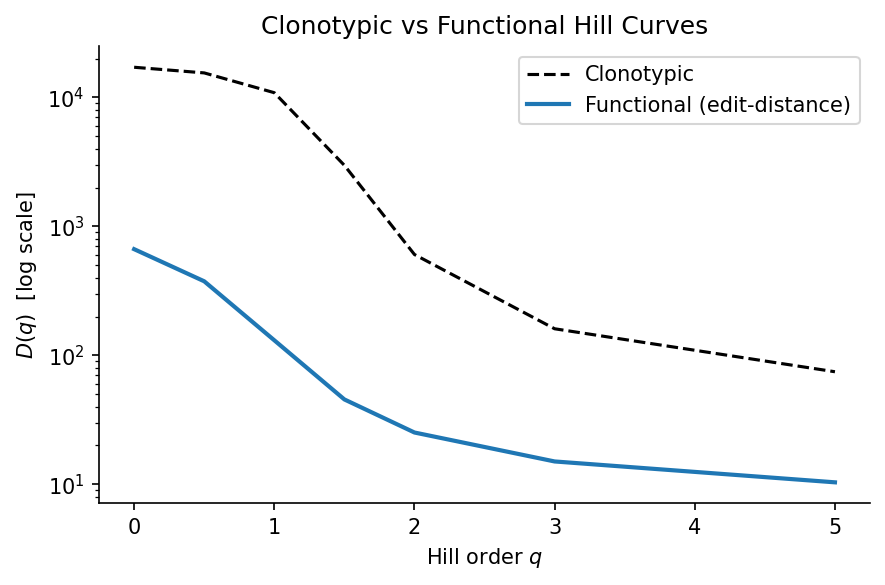

In [5]:
# Hill curves: clonotypic vs functional (edit-distance metaclonotypes)
q_values = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

hill_clono = hill_curve_clonotypes(rep.clonotypes, q_values=q_values)
hill_func  = functional_hill_curve(rep, meta, q_values=q_values)

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(hill_clono['q'], hill_clono['hill'], 'k--', lw=1.5, label='Clonotypic')
ax.plot(hill_func['q'],  hill_func['hill'],  'C0',  lw=2,   label='Functional (edit-distance)')
ax.set_yscale('log')
ax.set_xlabel('Hill order $q$')
ax.set_ylabel('$D(q)$  [log scale]')
ax.set_title('Clonotypic vs Functional Hill Curves')
ax.legend()
plt.tight_layout()
plt.show()

## Leiden graph clustering

`graph_algo='leiden'` merges multi-hop dense neighbourhoods; it finds fewer but larger clusters
than the `'components'` algorithm. Use Leiden when you want biologically coherent groupings
that bridge closely related but not directly linked CDR3s.

In [6]:
# Compare components vs Leiden graph algorithm
results = {}
for algo in ('components', 'leiden'):
    cfg_algo = MetaclonotypeClusterConfig(
        method='edit_distance',
        metric='hamming',
        threshold=1,
        graph_algo=algo,
        min_cluster_size=2,
        n_jobs=4,
    )
    m = cluster_metaclonotypes(rep, cfg_algo)
    d = functional_diversity(rep, m)
    results[algo] = {'n_clusters': m.n_clusters, 'shannon': d.shannon, 'gini_simpson': d.gini_simpson}
    print(f'{algo:12s}: clusters={m.n_clusters:,}  shannon={d.shannon:.3f}  gini_simpson={d.gini_simpson:.4f}')

print(f'\nLeiden / components cluster ratio: {results["leiden"]["n_clusters"] / results["components"]["n_clusters"]:.3f}')

Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


components  : clusters=666  shannon=4.874  gini_simpson=0.9603


Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 387 sequences with non-canonical amino acids (*, _, or non-standard chars)


leiden      : clusters=677  shannon=5.085  gini_simpson=0.9657

Leiden / components cluster ratio: 1.017


## ALICE-based metaclonotypes

ALICE detects statistically over-represented clonotypes (expanded beyond Pgen expectation).
`add_alice_metadata` runs the ALICE enrichment and stores q-values in each clonotype's
`clone_metadata`.  `MetaclonotypeClusterConfig(method='alice')` then wraps enriched
clonotypes and their 1-mismatch neighbours into metaclonotypes.

In [7]:
# Run ALICE enrichment, then build metaclonotypes from significant hits
rep_alice = add_alice_metadata(rep, species='human', metric='hamming', match_mode='vj', n_jobs=4)

cfg_alice = MetaclonotypeClusterConfig(method='alice', q_value_max=0.05)
meta_alice = cluster_metaclonotypes(rep_alice, cfg_alice)
div_alice  = functional_diversity(rep_alice, meta_alice)

print(f'ALICE metaclonotypes: {meta_alice.n_clusters:,} clusters')
print(f'Functional Shannon:   {div_alice.shannon:.3f}')
print(f'Functional Chao1:     {div_alice.chao1:.1f}')
print(f'\nTop ALICE clusters:')
print(summarize_metaclonotypes(rep_alice, meta_alice).sort('duplicate_count', descending=True).head(5))

Skipping 2 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 3 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 13 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


...

Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


Skipping 1 sequences with non-canonical amino acids (*, _, or non-standard chars)


ALICE metaclonotypes: 855 clusters
Functional Shannon:   5.136
Functional Chao1:     855.1

Top ALICE clusters:
shape: (5, 8)
┌────────────┬───────────┬────────────┬───────────┬────────────┬───────────┬───────────┬───────────┐
│ cluster_id ┆ n_members ┆ duplicate_ ┆ umi_count ┆ representa ┆ represent ┆ represent ┆ represent │
│ ---        ┆ ---       ┆ count      ┆ ---       ┆ tive_clono ┆ ative_jun ┆ ative_v_g ┆ ative_j_g │
│ str        ┆ u32       ┆ ---        ┆ i64       ┆ type_id    ┆ ction_aa  ┆ ene       ┆ ene       │
│            ┆           ┆ i64        ┆           ┆ ---        ┆ ---       ┆ ---       ┆ ---       │
│            ┆           ┆            ┆           ┆ str        ┆ str       ┆ str       ┆ str       │
╞════════════╪═══════════╪════════════╪═══════════╪════════════╪═══════════╪═══════════╪═══════════╡
│ alice_mc_0 ┆ 3         ┆ 631        ┆ 0         ┆ 0          ┆ CATATSGEH ┆ TRBV27*01 ┆ TRBJ2-3*0 │
│            ┆           ┆            ┆           ┆            ┆ T

## Method comparison summary

| Method | Config | Clusters | Notes |
|---|---|---|---|
| `edit_distance/components` | `threshold=1, graph_algo='components'` | small, tight | Exact 1-mismatch |
| `edit_distance/leiden` | `threshold=1, graph_algo='leiden'` | fewer, larger | Merges dense neighbourhoods |
| `alice` | `q_value_max=0.05` | enriched seeds | Statistically significant only |

For a full method comparison including TCRdist, TCREmp, and GLIPH, see [metaclonotype_method_compare.ipynb](metaclonotype_method_compare.ipynb).